In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

%matplotlib inline

df = pd.read_csv('data/train.csv')

# Osnovne informacije o tipovima podataka i null vrednostima
print(df.info())
print(df.describe())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 5.4 MB
None
        employee_id  no_of_trainings           age  previous_year_rating  

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [75]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

kolone poput education i previous_year_rating često imaju nedostajuće vrednosti.

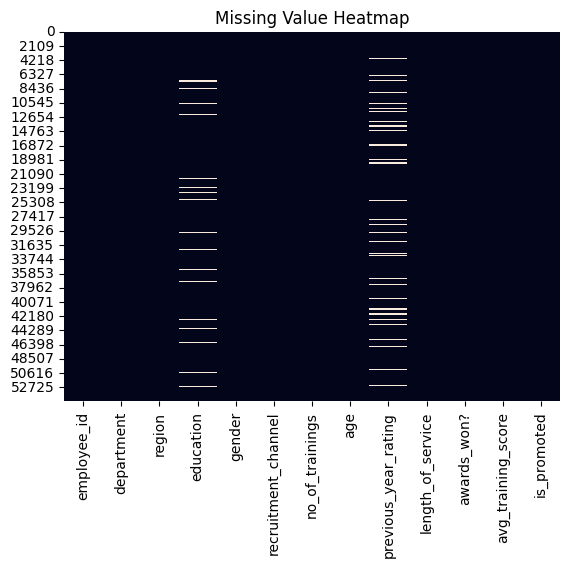

In [76]:
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [77]:
df['education'].value_counts()

education
Bachelor's          36669
Master's & above    14925
Below Secondary       805
Name: count, dtype: int64

In [78]:
print("Train \n",df['education'].value_counts(dropna = False , normalize = True)*100)


Train 
 education
Bachelor's          66.904467
Master's & above    27.231426
NaN                  4.395344
Below Secondary      1.468764
Name: proportion, dtype: float64


In [79]:
print(df['previous_year_rating'].value_counts())


previous_year_rating
3.0    18618
5.0    11741
4.0     9877
1.0     6223
2.0     4225
Name: count, dtype: int64


In [80]:
df.duplicated().sum()


np.int64(0)

In [81]:
missing_values = df.isnull().sum()
print("Nedostajuće vrednosti:\n", missing_values[missing_values > 0])

# Popunjavanje: obrazovanje sa 'unknown' ili modom, a ocenu sa 0 ili medijanom
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)

# Brisanje ID kolone jer ne utiče na model
df.drop('employee_id', axis=1, inplace=True)

Nedostajuće vrednosti:
 education               2409
previous_year_rating    4124
dtype: int64


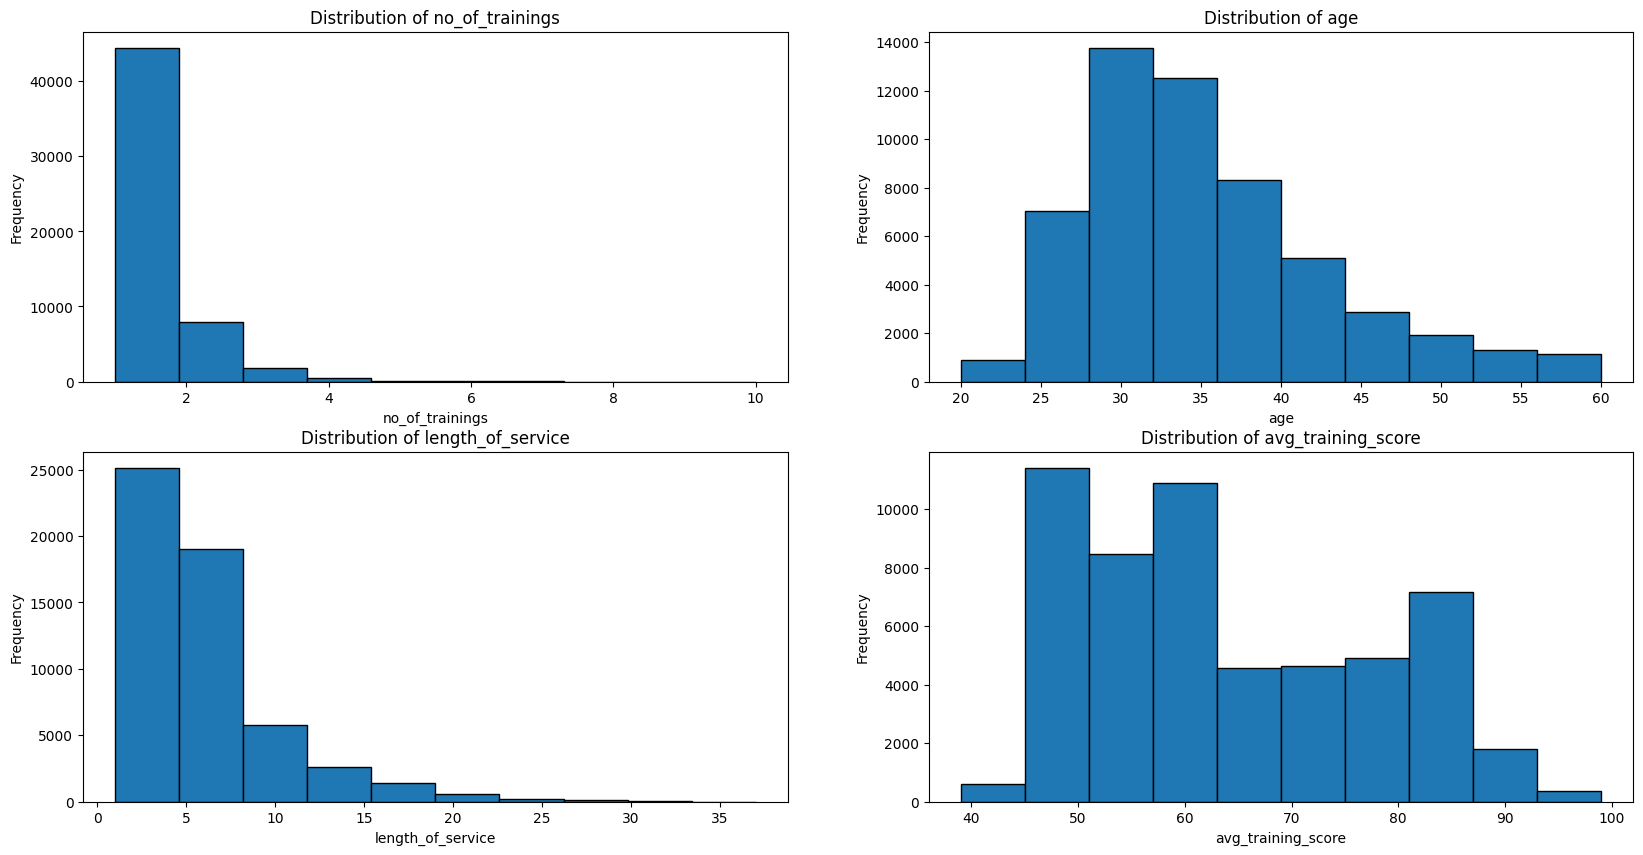

In [82]:
dist_cols = ['no_of_trainings', 'age', 'length_of_service', 'avg_training_score']
# histogram for outliers in df_train
i = 1
plt.figure(figsize=(20, 10))
for col in dist_cols:
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=10, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    i += 1
plt.show()

skup je nebalansiran kao sto smo i primetili. To je ključno vizuelizovati odmah, jer će uticati na izbor metrike (Accuracy neće biti dovoljan, trebaće nam F1-score).

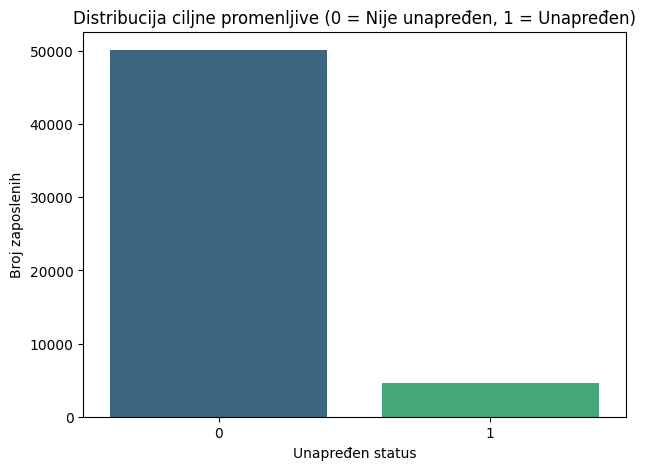

Procentualni udeo klasa:
is_promoted
0    91.482995
1     8.517005
Name: proportion, dtype: float64


In [83]:
plt.figure(figsize=(7,5))
sns.countplot(x='is_promoted', data=df, hue='is_promoted', palette='viridis', legend=False)

plt.title('Distribucija ciljne promenljive (0 = Nije unapređen, 1 = Unapređen)')
plt.xlabel('Unapređen status')
plt.ylabel('Broj zaposlenih')
plt.show()

# Precizan procentualni prikaz nebalansiranosti
print("Procentualni udeo klasa:")
print(df['is_promoted'].value_counts(normalize=True) * 100)

Da bismo videli koji faktori (npr. nagrade, ocene, godine staža) najviše utiču na napredovanje, koristimo graf prikaz.

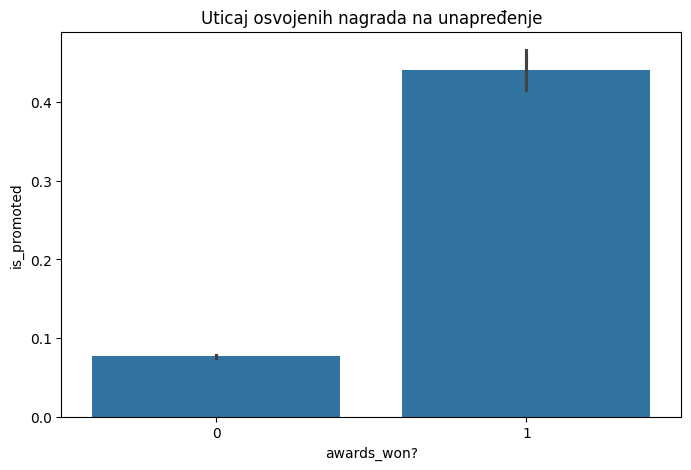

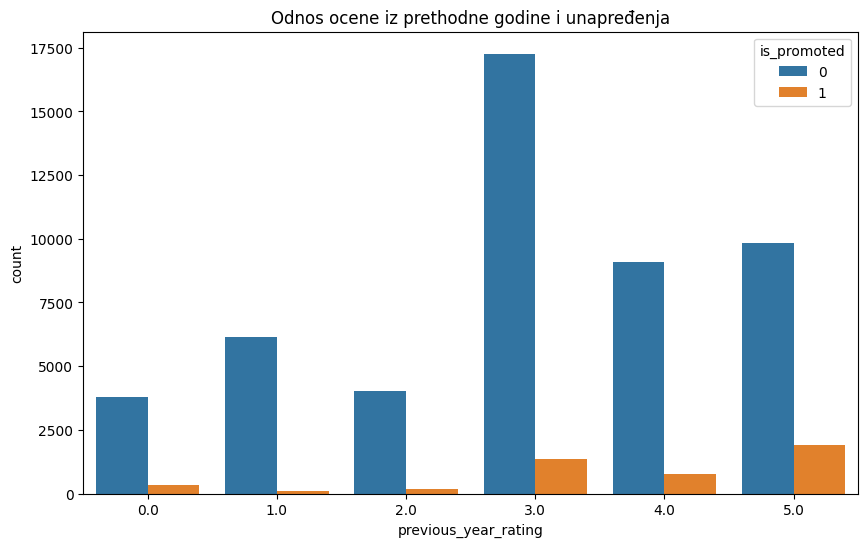

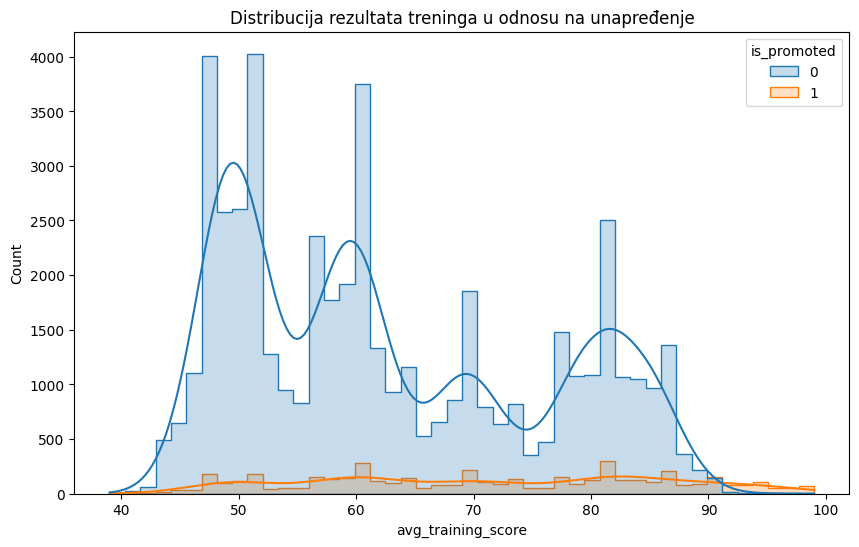

In [84]:
# Uticaj nagrada (awards_won?) na unapređenje
plt.figure(figsize=(8,5))
sns.barplot(x='awards_won?', y='is_promoted', data=df)
plt.title('Uticaj osvojenih nagrada na unapređenje')
plt.show()

# Uticaj ocene iz prethodne godine
plt.figure(figsize=(10,6))
sns.countplot(x='previous_year_rating', hue='is_promoted', data=df)
plt.title('Odnos ocene iz prethodne godine i unapređenja')
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='avg_training_score', hue='is_promoted', kde=True, element="step")
plt.title('Distribucija rezultata treninga u odnosu na unapređenje')
plt.show()

zaposleni koji su osvojili nagradu (vrednost 1) imaju drastično veće šanse za unapređenje (preko 40%) u odnosu na one bez nagrade (ispod 10%).

Najveći broj zaposlenih ima ocenu 3.0, ali je kod njih procenat unapređenja (narandzasti stubići) srazmerno mali u odnosu na ukupan broj.

Kod ocene 5.0, narandzasti stubic je najizrazeniji u odnosu na plavi, sto potvrdjuje da je previous_year_rating veliki faktor

sada cemo graficki prikazati uticaj demografskih faktora na sansu unapredjenja

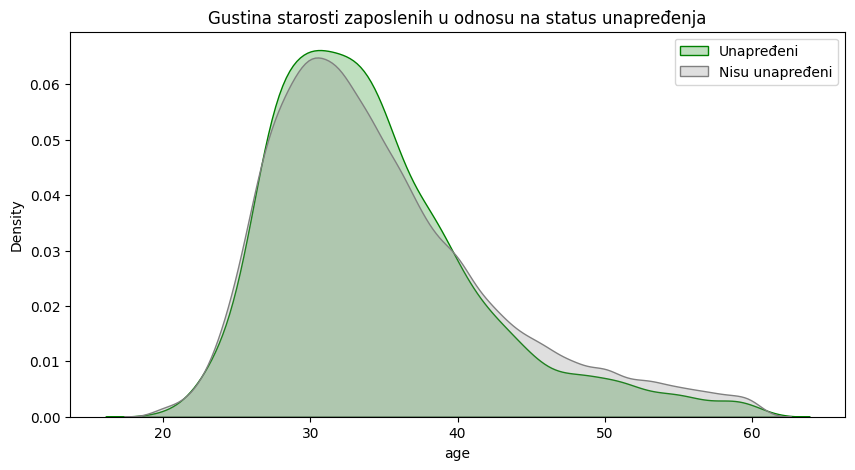

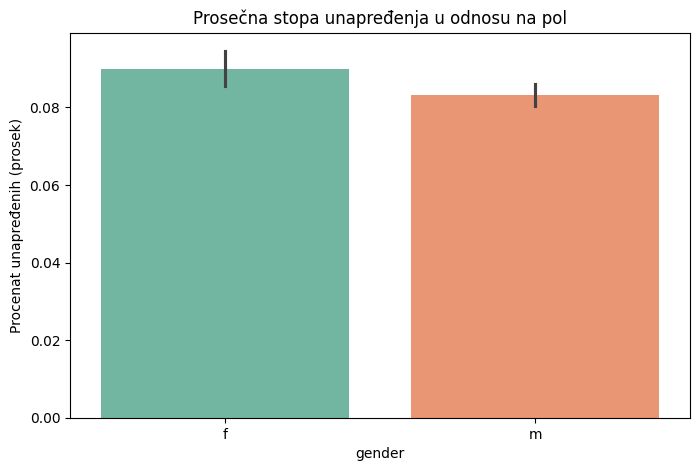

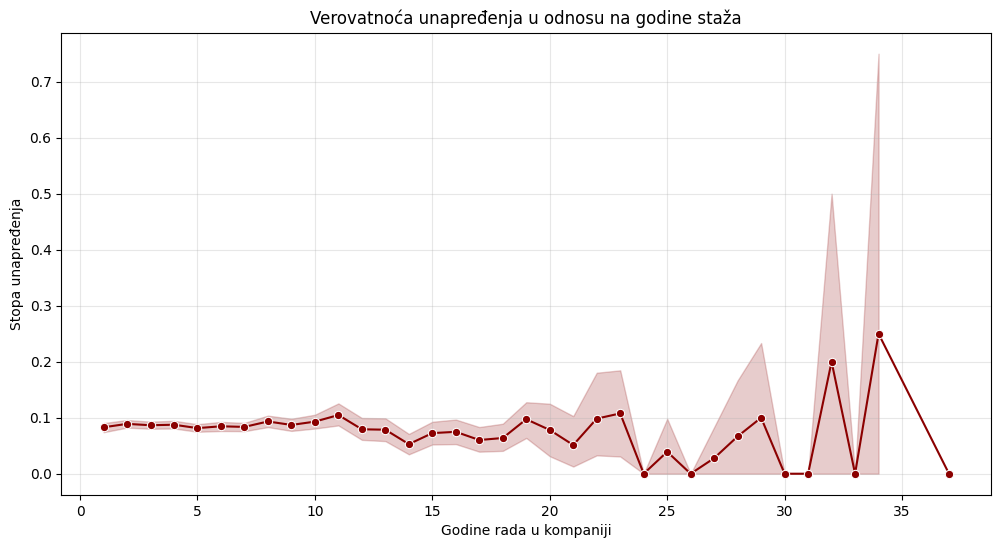

In [85]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['is_promoted'] == 1], x='age', label='Unapređeni', fill=True, color='green')
sns.kdeplot(data=df[df['is_promoted'] == 0], x='age', label='Nisu unapređeni', fill=True, color='grey')
plt.title('Gustina starosti zaposlenih u odnosu na status unapređenja')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='is_promoted', data=df, hue='gender', palette='Set2', legend=False)
plt.title('Prosečna stopa unapređenja u odnosu na pol')
plt.ylabel('Procenat unapređenih (prosek)')
plt.show()

plt.figure(figsize=(12,6))
sns.lineplot(x='length_of_service', y='is_promoted', data=df, color='darkred', marker='o')
plt.title('Verovatnoća unapređenja u odnosu na godine staža')
plt.xlabel('Godine rada u kompaniji')
plt.ylabel('Stopa unapređenja')
plt.grid(True, alpha=0.3)
plt.show()

stopa unapređenja kod zena (f) za nijansu veća nego kod muskaraca (m). Iako je razlika mala (oko 0.09 naspram 0.08), ovo je vazan uvid jer sugeriše da pol nije prepreka za napredovanje u ovoj kompaniji.

Između 1 i 20 godina rada, stopa unapređenja je prilično stabilna i niska. Nakon 30 godina rada primećuju se veliki skokovi u sansi unapredjenja

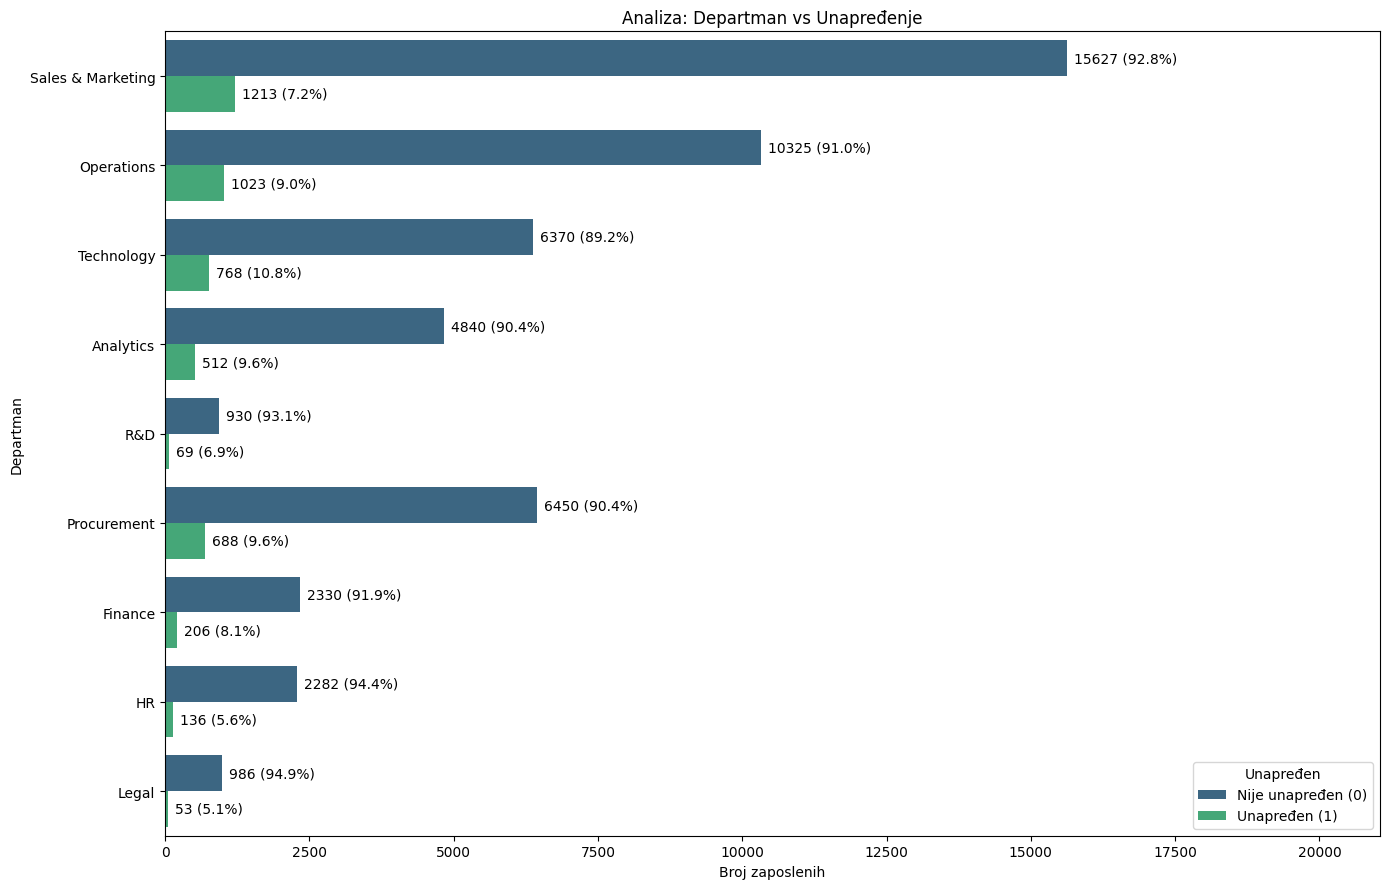

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(14, 9))

ax = sns.countplot(y="department", hue="is_promoted", data=df, palette='viridis')

totals = df.groupby('department').size()
order = [label.get_text() for label in ax.get_yticklabels()]

for i, container in enumerate(ax.containers):
    labels = []
    for j, v in enumerate(container):
        count = v.get_width()
        dept_name = order[j]
        total = totals[dept_name]
        percentage = (count / total) * 100
        labels.append(f'{int(count)} ({percentage:.1f}%)')
    
    ax.bar_label(container, labels=labels, padding=5, fontsize=10)

plt.title("Analiza: Departman vs Unapređenje")
plt.xlabel("Broj zaposlenih")
plt.ylabel("Departman")
plt.legend(title='Unapređen', labels=['Nije unapređen (0)', 'Unapređen (1)'], loc='lower right')

plt.xlim(0, df['department'].value_counts().max() * 1.25)

plt.tight_layout()
plt.show()

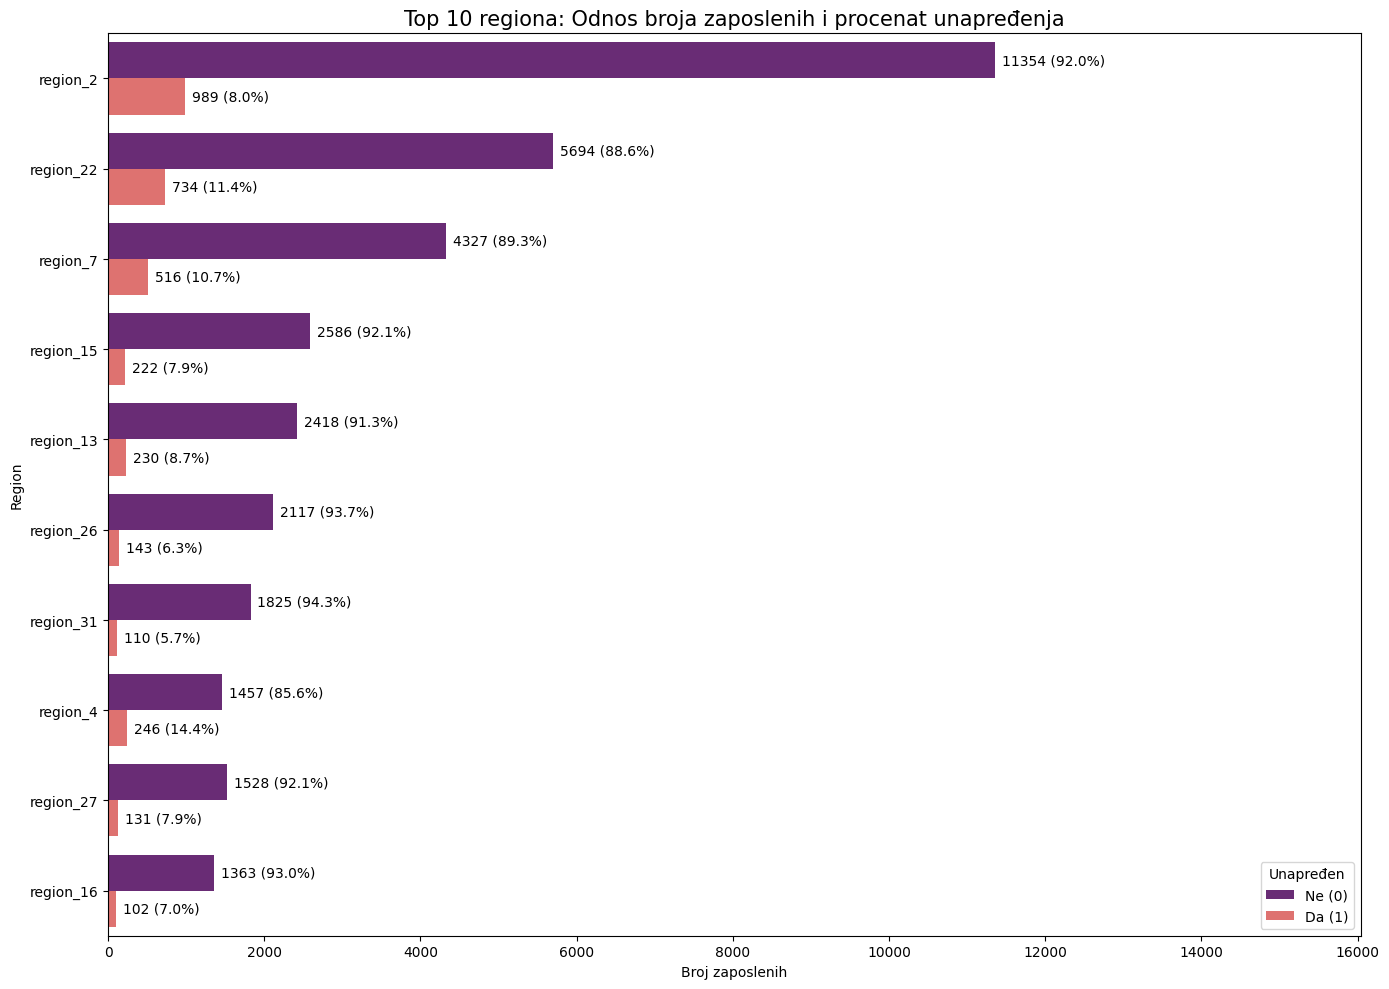

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pronalaženje top 10 regiona po broju zaposlenih
top_regions = df['region'].value_counts().head(10).index
df_top_regions = df[df['region'].isin(top_regions)]

plt.figure(figsize=(14, 10))

# 2. Kreiranje countplot-a
ax = sns.countplot(y="region", hue="is_promoted", data=df_top_regions, 
                   palette='magma', order=top_regions)

# 3. Računanje ukupnih vrednosti za procente (samo za ovih 10 regiona)
region_totals = df_top_regions.groupby('region').size()

# 4. Dodavanje labela (broj i procenat)
for container in ax.containers:
    labels = []
    for i, v in enumerate(container):
        count = v.get_width()
        # Provera da li je bar vidljiv (da izbegnemo greške kod nula)
        if count > 0:
            region_name = top_regions[i]
            total = region_totals[region_name]
            percentage = (count / total) * 100
            labels.append(f'{int(count)} ({percentage:.1f}%)')
        else:
            labels.append('0 (0.0%)')
    
    ax.bar_label(container, labels=labels, padding=5, fontsize=10)

plt.title("Top 10 regiona: Odnos broja zaposlenih i procenat unapređenja", fontsize=15)
plt.xlabel("Broj zaposlenih")
plt.ylabel("Region")
plt.legend(title='Unapređen', labels=['Ne (0)', 'Da (1)'], loc='lower right')

# Proširujemo X osu da tekst ne udara u ivicu
plt.xlim(0, df_top_regions['region'].value_counts().max() * 1.3)

plt.tight_layout()
plt.show()

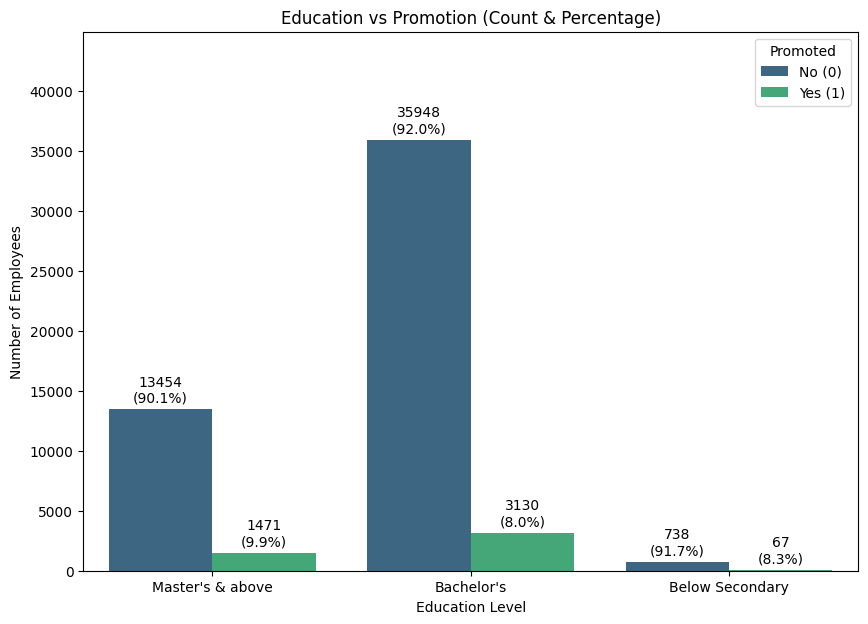

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
ax = sns.countplot(x="education", hue="is_promoted", data=df, palette='viridis')

total_per_edu = df.groupby('education').size()
edu_order = [label.get_text() for label in ax.get_xticklabels()]

for container in ax.containers:
    labels = []
    for i, v in enumerate(container):
        count = v.get_height()
        if count > 0:
            edu_name = edu_order[i]
            total = total_per_edu[edu_name]
            percentage = (count / total) * 100
            labels.append(f'{int(count)}\n({percentage:.1f}%)')
        else:
            labels.append('0 (0.0%)')
    
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title("Education vs Promotion (Count & Percentage)")
plt.xlabel("Education Level")
plt.ylabel("Number of Employees")
plt.legend(title='Promoted', labels=['No (0)', 'Yes (1)'])
plt.ylim(0, df['education'].value_counts().max() * 1.15)
plt.show()

Za kolone sa malo kategorija (kao što je gender) koristimo Label Encoding, a za one sa više (kao što su department ili region) koristimo One-Hot Encoding (tzv. "dummy" varijable).

In [89]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding za pol (M/F)
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# One-Hot Encoding za ostale kategoričke kolone
# Ovo će kreirati nove kolone za svaki departman i region
df = pd.get_dummies(df, columns=['department', 'region', 'education', 'recruitment_channel'], drop_first=True)
print(f"Novi broj kolona nakon enkodiranja: {df.shape[1]}")

Novi broj kolona nakon enkodiranja: 53


Sada kada su nam svi podaci numerički, možemo generisati matricu korelacije da vidimo koji su atributi najuže povezani sa ciljnim atributom is_promoted.

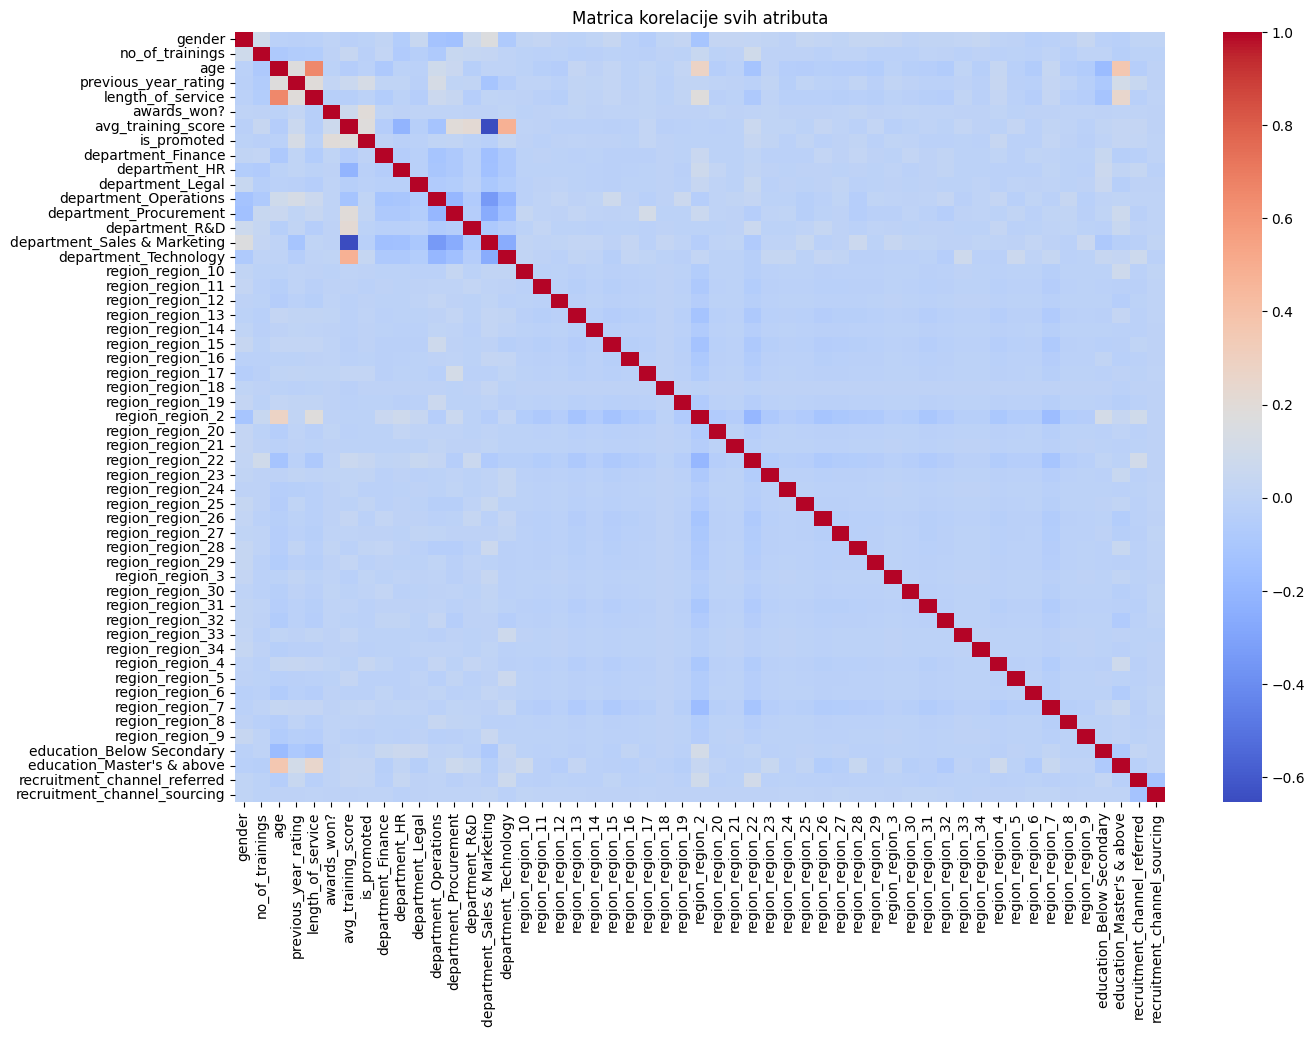

In [90]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm') 
plt.title('Matrica korelacije svih atributa')
plt.show()

In [91]:
# Izvlačenje korelacije svih atributa direktno sa metom (is_promoted)
korelacije = df.corr(numeric_only=True)['is_promoted'].sort_values(ascending=False)
print("Brojčani uticaj na unapređenje:\n", korelacije)

Brojčani uticaj na unapređenje:
 is_promoted                     1.000000
awards_won?                     0.195871
avg_training_score              0.181147
previous_year_rating            0.125991
region_region_4                 0.038031
region_region_22                0.037893
department_Technology           0.031085
education_Master's & above      0.029343
region_region_7                 0.023841
region_region_17                0.022513
recruitment_channel_referred    0.018641
region_region_25                0.017911
region_region_28                0.017812
region_region_23                0.016664
department_Procurement          0.015548
department_Operations           0.009113
region_region_3                 0.006215
region_region_30                0.001828
region_region_13                0.001363
recruitment_channel_sourcing   -0.000483
education_Below Secondary      -0.000849
region_region_8                -0.001676
region_region_10               -0.002534
department_Finance      

Matrica korelacije potvrđuje da demografski faktori (pol, region) imaju zanemarljiv uticaj na uspeh, dok su profesionalni rezultati poput avg_training_score i awards_won ključni faktori korelirani sa ciljnom promenljivom is_promoted. takodje previous year rating ima odredjeni uticaj na unapredjenje.

Master's & above (0.0293): Viši nivo obrazovanja ima blago pozitivan uticaj u poređenju sa osnovnim studijama.

Department_Technology (0.0311): Zaposleni u IT sektoru imaju statistički nešto veću prohodnost ka višim pozicijama.

Region_region_4 i Region_region_22: Ovi regioni se izdvajaju kao lokacije sa nešto većom stopom unapređenja, verovatno veliki gradovi ili sedišta firme

no_of_trainings (-0.0248): Interesantan uvid – preveliki broj treninga blago korelira sa manjom šansom za unapređenje. To može značiti da zaposleni koji idu na previše obuka to rade jer im nedostaju osnovne veštine.

department_Sales & Marketing (-0.0313): U ovom sektoru je statistički teže doći do unapređenja u poređenju sa ostalima, verovatno zbog velike konkurencije.

recruitment_channel_sourcing (-0.0004): Način na koji je radnik pronađen (sourcing) skoro uopšte ne utiče na njegovu buduću karijeru, što ukazuje na fer sistem ocenjivanja nakon zaposlenja.

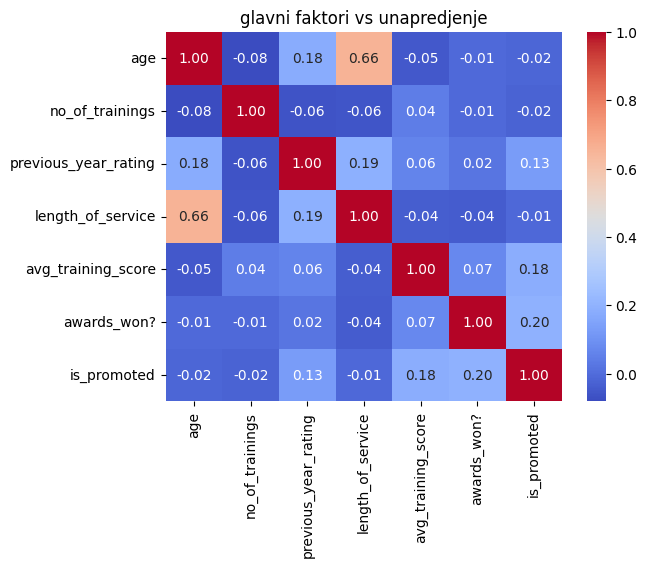

In [92]:
num_cols = [
    "age",
    "no_of_trainings",
    "previous_year_rating",
    "length_of_service",
    "avg_training_score",
    "awards_won?",
    "is_promoted"
]

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("glavni faktori vs unapredjenje")
plt.show()

Da ne bi ostalo samo na brojevima, uvek je dobro dodati mali horizontalni bar grafik koji pokazuje ove vrednosti:

C:\Users\PC\AppData\Local\Temp\ipykernel_21528\2761886031.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='Reds_r')


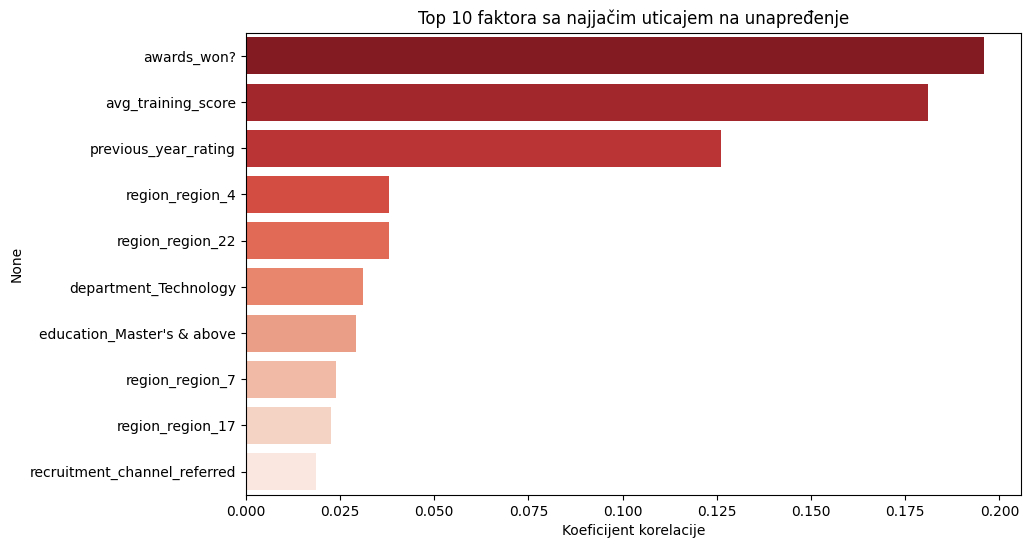

In [93]:
# Izdvajanje top 10 korelacija
top_corr = korelacije[1:11] 

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='Reds_r')
plt.title('Top 10 faktora sa najjačim uticajem na unapređenje')
plt.xlabel('Koeficijent korelacije')
plt.show()

Pre nego što rešimo problem nebalansiranosti, moramo podeliti podatke kako ne bi došlo do "curenja" informacija iz test skupa u trening proces.

In [94]:
from sklearn.model_selection import train_test_split

X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

vrlo mali procenat ljudi je unapređen (obično oko 8-10%). Ako bismo sada pustili model, on bi naučio da samo "pogađa" da niko nije unapređen i imao bi visoku preciznost, ali bi bio beskoristan.

Koristićemo SMOTE (Synthetic Minority Over-sampling Technique) koji veštački kreira nove primere unapređenih zaposlenih na osnovu postojećih.

In [95]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Broj uzoraka pre SMOTE-a: {y_train.value_counts()}")
print(f"Broj uzoraka nakon SMOTE-a: {y_train_res.value_counts()}")

Broj uzoraka pre SMOTE-a: is_promoted
0    35097
1     3268
Name: count, dtype: int64
Broj uzoraka nakon SMOTE-a: is_promoted
0    35097
1    35097
Name: count, dtype: int64


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    predictions = model.predict(X_test)
    score = f1_score(y_test, predictions)
    results[name] = score
    print(f"{name} F1-Score: {score:.4f}")

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression F1-Score: 0.4239
Random Forest F1-Score: 0.4020
Gradient Boosting F1-Score: 0.3887
XGBoost F1-Score: 0.4751


Ovi rezultati su odlični jer se savršeno uklapaju u pisani rad.

Prema literaturi, XGBoost je prepoznat kao model koji postiže najbolje rezultate, što je tvoj kod upravo i dokazao sa najvišim F1-Score-om od 0.4751.

Logistička regresija je postigla solidnih 0.4239, što potvrdjuje pretpostavku da je ona dobar polazni osnov za poređenje. Pošto je XGBoost pobednik, sada moramo primeniti Grid Search baš na njega kako bismo izvukli maksimum i završili taj deo obećane metodologije.

In [97]:
from sklearn.model_selection import GridSearchCV

# Definisanje parametara za XGBoost(Grid Search)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

# Inicijalizacija Grid Search-a sa 5-fold kros-validacijom (Tačka 5)
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), 
                        param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)

grid_xgb.fit(X_train_res, y_train_res)

print(f"Najbolji parametri za XGBoost: {grid_xgb.best_params_}")
print(f"Najbolji F1-Score nakon optimizacije: {grid_xgb.best_score_:.4f}")

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:57:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Najbolji parametri za XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Najbolji F1-Score nakon optimizacije: 0.9306
